In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
df = pd.read_csv("telangana_district_crime_totals_clean.csv")
print(df.head())

     District  Total_2018  Total_2017  Total_2016
0   Cyberabad       16168       19654       12194
1   Hyderabad       13793       13781       15526
2  Karimnagar        3394        3454        3410
3     Khammam        5195        6223        5207
4   Nizamabad        3602        3401        3399


In [5]:
df_long = df.melt(
    id_vars=['District'],
    var_name='Year',
    value_name='Crime_Count'
)

# Extract year number
df_long['Year'] = df_long['Year'].str.extract(r'(\d+)').astype(int)

print(df_long.head())

     District  Year  Crime_Count
0   Cyberabad  2018        16168
1   Hyderabad  2018        13793
2  Karimnagar  2018         3394
3     Khammam  2018         5195
4   Nizamabad  2018         3602


In [6]:
df_long = df_long.dropna()

df_long['Crime_Count'] = df_long['Crime_Count'].astype(float)


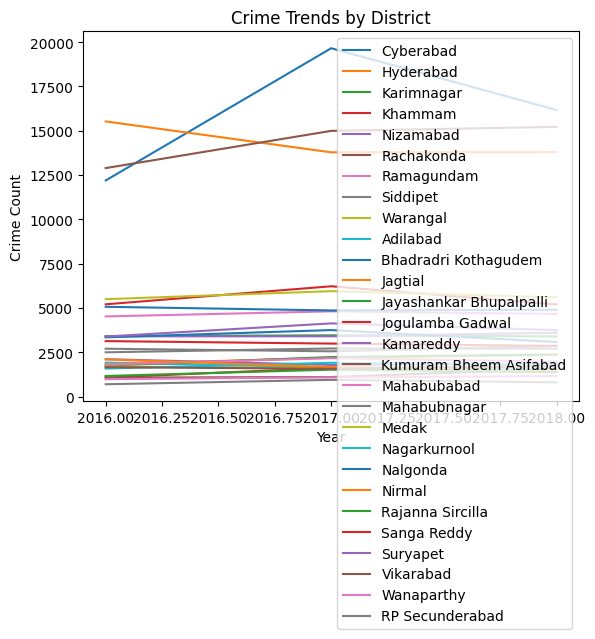

In [7]:
for district in df_long['District'].unique():
    data = df_long[df_long['District'] == district]
    plt.plot(data['Year'], data['Crime_Count'], label=district)

plt.legend()
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crime Trends by District")
plt.show()

In [8]:
models = {}
scores = {}

for district in df_long['District'].unique():
    data = df_long[df_long['District'] == district]
    
    X = data[['Year']]
    y = data['Crime_Count']
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    models[district] = model
    scores[district] = (r2, mae)

In [11]:
final_models = {}

for district, (r2, mae) in scores.items():
    if r2 >= 0.6:
        final_models[district] = models[district]

In [22]:
def predict_district_crime(year):
    results = []
    
    for district, model in final_models.items():
        input_df = pd.DataFrame([[year]], columns=['Year'])
        pred = round(model.predict(input_df)[0])
        
        results.append([district, pred])
    
    return results

In [25]:
year = int(input("Enter year: "))

predictions = predict_district_crime(year)

pred_df = pd.DataFrame(predictions, columns=["District", "Predicted_Crime"])
print(pred_df)

Enter year:  2024


                   District  Predicted_Crime
0                 Hyderabad             8301
1                 Nizamabad             4178
2                Rachakonda            22501
3                  Adilabad              484
4                   Jagtial             3974
5   Jayashankar Bhupalpalli             4343
6    Kumuram Bheem Asifabad             2964
7              Mahabubnagar             3364
8                    Nirmal             -723
9               Sanga Reddy             2048
10               Wanaparthy             1680


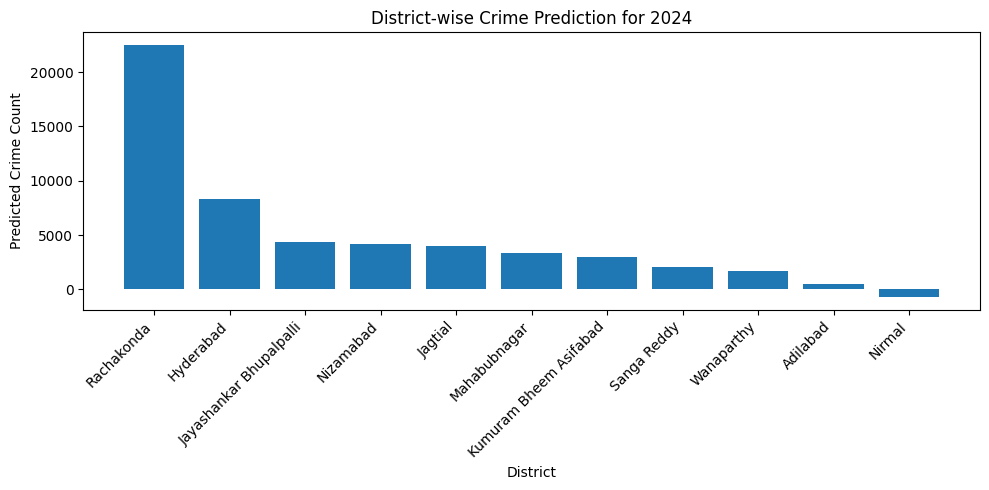

In [26]:
pred_df_sorted = pred_df.sort_values(by='Predicted_Crime', ascending=False)

plt.figure(figsize=(10,5))

plt.bar(pred_df_sorted['District'], pred_df_sorted['Predicted_Crime'])

plt.xticks(rotation=45, ha='right')
plt.xlabel("District")
plt.ylabel("Predicted Crime Count")
plt.title(f"District-wise Crime Prediction for {year}")

plt.tight_layout()
plt.show()